# 12. Métricas Extendidas (NDCG@K, HitRate@K) e Intervalos de Confianza Bootstrap

Cierra dos vacíos del Capítulo 3: (i) reporta **NDCG@K** y **HitRate@K**, prometidas en el alcance pero nunca calculadas; (ii) añade **intervalos de confianza bootstrap (95 %)** a todas las métricas. Primero **reproduce** los números canónicos (`models/evaluation_results.txt`, N=2000, seed=42) como prueba de regresión, garantizando que el arnés es fiel antes de confiar en las métricas nuevas. Finalmente regenera figuras consistentes con la Tabla 11.

**Nota v2:** la línea base SVD fue sustituida por la **co-ocurrencia ítem-ítem (conteo +pop)** — el baseline clásico que sí condiciona sobre el producto-semilla (ver cuaderno 16 para el estudio completo de variantes y la justificación).

In [1]:
import os
# Kernel CWD robusto: subir hasta la raíz del proyecto (donde vive data_processed/)
_d = os.getcwd()
while not os.path.isdir("data_processed") and os.path.dirname(_d) != _d:
    os.chdir(".."); _d = os.getcwd()
assert os.path.isdir("data_processed"), f"No se encontró data_processed/ desde {os.getcwd()}"
print("CWD del kernel:", os.getcwd())

CWD del kernel: /Users/allan/Documents/maestria/tesis v4


In [2]:
import polars as pl
import numpy as np
import tensorflow as tf
import tensorflow_recommenders as tfrs
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time, os
np.random.seed(42)
tf.random.set_seed(42)
sns.set_theme(style="whitegrid")
K_LIST = [10, 50, 100]
print("TF", tf.__version__, "| Polars", pl.__version__)

TF 2.21.0 | Polars 1.41.2


In [3]:
# --- Datos (idéntico a 07_offline_evaluation) ---
train_df = pl.read_parquet("data_processed/retrieval_train.parquet")
val_df = pl.read_parquet("data_processed/retrieval_val.parquet")
products_df = pl.read_parquet("data_processed/products_catalog.parquet").unique(subset=["id_producto"])

products_df = products_df.with_columns([
    pl.col("marca").fill_null("SIN_MARCA"),
    pl.col("familia1").fill_null("SIN_CATEGORIA"),
    pl.col("familia2").fill_null("SIN_SUBCATEGORIA"),
    pl.col("precio").fill_null(0.0),
    pl.col("peso_unitario").fill_null(0.0),
])
cand_cols_rename = {c: f"cand_{c}" if c != "id_producto" else c for c in products_df.columns}
products_renamed = products_df.rename(cand_cols_rename)
val_joined = val_df.join(products_renamed, left_on="COD_PROD_2", right_on="id_producto", how="left").rename({
    "cand_marca": "marca_2", "cand_familia1": "familia1_2", "cand_familia2": "familia2_2",
    "cand_precio": "precio_2", "cand_peso_unitario": "peso_unitario_2",
}).with_columns([
    pl.col("marca_2").fill_null("SIN_MARCA"), pl.col("familia1_2").fill_null("SIN_CATEGORIA"),
    pl.col("familia2_2").fill_null("SIN_SUBCATEGORIA"), pl.col("precio_2").fill_null(0.0),
    pl.col("peso_unitario_2").fill_null(0.0),
])
# Misma muestra canónica: N = 2000, seed = 42
val_sample = val_joined.sample(n=min(2000, val_joined.height), seed=42)
N_QUERIES = val_sample.height
print(f"N consultas de evaluacion = {N_QUERIES} (seed=42)")
catalog_ids = products_df["id_producto"].to_list()
catalog_arr = np.array(catalog_ids)
id2col = {pid: i for i, pid in enumerate(catalog_ids)}

N consultas de evaluacion = 2000 (seed=42)


## 1. Baseline Popularidad — rangos por consulta

In [4]:
popularity = train_df.group_by("COD_PROD_2").agg(pl.len().alias("count")).sort("count", descending=True)
pop_ids = popularity["COD_PROD_2"].to_numpy()
missing = [p for p in catalog_ids if p not in set(pop_ids)]
popularity_list = np.concatenate([pop_ids, np.array(missing)])
pop_pos = {pid: i for i, pid in enumerate(popularity_list)}
targets = val_sample["COD_PROD_2"].to_numpy()

def ranks_pop(targets):
    r = np.full(len(targets), np.inf)
    for i, t in enumerate(targets):
        if t in pop_pos:
            r[i] = pop_pos[t] + 1
    return r
pop_ranks = ranks_pop(targets)

## 2. Baseline de co-ocurrencia ítem-ítem (conteo +pop) — rangos por consulta

In [5]:
# Baseline clásico condicionado a la semilla: co-ocurrencia ítem-ítem, variante conteo (+pop).
# score(j | i) = N(i,j) (equivale a P(j|i) en ranking); los candidatos sin co-ocurrencia se
# ordenan por popularidad a continuación del bloque con co-ocurrencia (relleno estándar de
# producción). Empates dentro del bloque: por popularidad, determinista. Ver cuaderno 16.
cooc = train_df.group_by(["COD_PROD", "COD_PROD_2"]).agg(pl.len().alias("n_ij"))
seeds_eval = sorted(set(val_sample["COD_PROD"].to_list()))
neigh = {}
for grp in cooc.filter(pl.col("COD_PROD").is_in(seeds_eval)).partition_by("COD_PROD"):
    s = grp["COD_PROD"][0]
    cand = grp["COD_PROD_2"].to_numpy()
    neigh[s] = (cand, grp["n_ij"].to_numpy().astype(float),
                np.array([pop_pos[c] for c in cand]))

def ranks_cooc(qdf, targets):
    seeds = qdf["COD_PROD"].to_list()
    r = np.full(len(targets), np.inf)
    for i in range(len(targets)):
        t = targets[i]; t_pop = pop_pos.get(t)
        nb = neigh.get(seeds[i])
        if nb is None:
            if t_pop is not None:
                r[i] = t_pop + 1  # semilla no vista: pura popularidad
            continue
        cand, n_ij, cand_pop = nb
        order = np.lexsort((cand_pop, -n_ij))
        pos = np.where(cand[order] == t)[0]
        if len(pos):
            r[i] = pos[0] + 1
        elif t_pop is not None:
            better_nb = int(np.sum(cand_pop < t_pop))
            r[i] = len(cand) + (t_pop - better_nb) + 1
    return r
cooc_ranks = ranks_cooc(val_sample, targets)
seen = sum(1 for s in val_sample["COD_PROD"].to_list() if s in neigh)
print(f"Semillas de evaluación con vecinos en train: {seen}/{N_QUERIES} ({seen/N_QUERIES*100:.1f} %)")

Semillas de evaluación con vecinos en train: 1967/2000 (98.4 %)


## 3. Two Towers — rangos por consulta

In [6]:
# --- Vocabularios y arquitectura (idéntico a 06/07) ---
vocab_ruc = sorted(train_df["RUC"].unique().to_list())
vocab_ciudad = sorted(train_df["CIUDAD"].unique().to_list())
vocab_ruta = sorted(train_df["RUTA"].unique().to_list())
vocab_products = sorted(products_df["id_producto"].unique().to_list())
vocab_marca = sorted(products_df["marca"].unique().to_list())
vocab_familia1 = sorted(products_df["familia1"].unique().to_list())
vocab_familia2 = sorted(products_df["familia2"].unique().to_list())

class QueryTower(tf.keras.Model):
    def __init__(self, vocab_ruc, vocab_ciudad, vocab_ruta, vocab_products, embedding_dim=128, dropout_rate=0.2):
        super().__init__()
        self.ruc_lookup = tf.keras.layers.StringLookup(vocabulary=vocab_ruc, mask_token=None)
        self.ruc_embedding = tf.keras.layers.Embedding(len(vocab_ruc) + 1, 64, name="ruc_emb")
        self.ciudad_lookup = tf.keras.layers.StringLookup(vocabulary=vocab_ciudad, mask_token=None)
        self.ciudad_embedding = tf.keras.layers.Embedding(len(vocab_ciudad) + 1, 16, name="ciudad_emb")
        self.ruta_lookup = tf.keras.layers.StringLookup(vocabulary=vocab_ruta, mask_token=None)
        self.ruta_embedding = tf.keras.layers.Embedding(len(vocab_ruta) + 1, 32, name="ruta_emb")
        self.product_lookup = tf.keras.layers.StringLookup(vocabulary=vocab_products, mask_token=None)
        self.product_embedding = tf.keras.layers.Embedding(len(vocab_products) + 1, 64, name="product_emb")
        self.geo_normalization = tf.keras.layers.Normalization(axis=-1)
        self.mlp = tf.keras.Sequential([
            tf.keras.layers.Dense(256, activation="relu"), tf.keras.layers.Dropout(dropout_rate),
            tf.keras.layers.Dense(128, activation="relu"), tf.keras.layers.Dropout(dropout_rate),
            tf.keras.layers.Dense(embedding_dim, name="query_projection")])
    def call(self, inputs):
        ruc_emb = self.ruc_embedding(self.ruc_lookup(inputs["RUC"]))
        ciudad_emb = self.ciudad_embedding(self.ciudad_lookup(inputs["CIUDAD"]))
        ruta_emb = self.ruta_embedding(self.ruta_lookup(inputs["RUTA"]))
        product_emb = self.product_embedding(self.product_lookup(inputs["COD_PROD"]))
        lat = tf.expand_dims(inputs["LATITUD"], axis=-1); lon = tf.expand_dims(inputs["LONGITUD"], axis=-1)
        geo_norm = self.geo_normalization(tf.concat([lat, lon], axis=-1))
        return tf.math.l2_normalize(self.mlp(tf.concat([ruc_emb, ciudad_emb, ruta_emb, product_emb, geo_norm], axis=-1)), axis=-1)

class CandidateTower(tf.keras.Model):
    def __init__(self, vocab_products, vocab_marca, vocab_familia1, vocab_familia2, embedding_dim=128, dropout_rate=0.2):
        super().__init__()
        self.product_lookup = tf.keras.layers.StringLookup(vocabulary=vocab_products, mask_token=None)
        self.product_embedding = tf.keras.layers.Embedding(len(vocab_products) + 1, 64, name="candidate_product_emb")
        self.marca_lookup = tf.keras.layers.StringLookup(vocabulary=vocab_marca, mask_token=None)
        self.marca_embedding = tf.keras.layers.Embedding(len(vocab_marca) + 1, 16, name="candidate_marca_emb")
        self.fam1_lookup = tf.keras.layers.StringLookup(vocabulary=vocab_familia1, mask_token=None)
        self.fam1_embedding = tf.keras.layers.Embedding(len(vocab_familia1) + 1, 16, name="candidate_fam1_emb")
        self.fam2_lookup = tf.keras.layers.StringLookup(vocabulary=vocab_familia2, mask_token=None)
        self.fam2_embedding = tf.keras.layers.Embedding(len(vocab_familia2) + 1, 16, name="candidate_fam2_emb")
        self.continuous_normalization = tf.keras.layers.Normalization(axis=-1)
        self.mlp = tf.keras.Sequential([
            tf.keras.layers.Dense(256, activation="relu"), tf.keras.layers.Dropout(dropout_rate),
            tf.keras.layers.Dense(128, activation="relu"), tf.keras.layers.Dropout(dropout_rate),
            tf.keras.layers.Dense(embedding_dim, name="candidate_projection")])
    def call(self, inputs):
        prod_emb = self.product_embedding(self.product_lookup(inputs["id_producto"]))
        marca_emb = self.marca_embedding(self.marca_lookup(inputs["marca"]))
        fam1_emb = self.fam1_embedding(self.fam1_lookup(inputs["familia1"]))
        fam2_emb = self.fam2_embedding(self.fam2_lookup(inputs["familia2"]))
        precio = tf.expand_dims(inputs["precio"], axis=-1); peso = tf.expand_dims(inputs["peso_unitario"], axis=-1)
        cont_norm = self.continuous_normalization(tf.concat([precio, peso], axis=-1))
        return tf.math.l2_normalize(self.mlp(tf.concat([prod_emb, marca_emb, fam1_emb, fam2_emb, cont_norm], axis=-1)), axis=-1)

In [7]:
def adapt_and_init(qt, ct):
    geo_train = train_df.select(["LATITUD", "LONGITUD"]).sample(n=100_000, seed=42).to_numpy().astype(np.float32)
    qt.geo_normalization.adapt(geo_train)
    cont_train = products_df.select(["precio", "peso_unitario"]).to_numpy().astype(np.float32)
    ct.continuous_normalization.adapt(cont_train)
    dq = {"RUC": tf.constant([vocab_ruc[0]]), "CIUDAD": tf.constant([vocab_ciudad[0]]),
          "RUTA": tf.constant([vocab_ruta[0]]), "LATITUD": tf.constant([0.0], dtype=tf.float32),
          "LONGITUD": tf.constant([0.0], dtype=tf.float32), "COD_PROD": tf.constant([vocab_products[0]])}
    dc = {"id_producto": tf.constant([vocab_products[0]]), "marca": tf.constant([vocab_marca[0]]),
          "familia1": tf.constant([vocab_familia1[0]]), "familia2": tf.constant([vocab_familia2[0]]),
          "precio": tf.constant([0.0], dtype=tf.float32), "peso_unitario": tf.constant([0.0], dtype=tf.float32)}
    _ = qt(dq); _ = ct(dc)

def candidate_embeddings(ct, pdf):
    ds = tf.data.Dataset.from_tensor_slices({
        "id_producto": pdf["id_producto"].to_numpy(), "marca": pdf["marca"].to_numpy(),
        "familia1": pdf["familia1"].to_numpy(), "familia2": pdf["familia2"].to_numpy(),
        "precio": pdf["precio"].to_numpy().astype(np.float32),
        "peso_unitario": pdf["peso_unitario"].to_numpy().astype(np.float32)}).batch(1024)
    return tf.concat([ct(b) for b in ds], axis=0)

def query_embeddings(qt, qdf):
    ds = tf.data.Dataset.from_tensor_slices({
        "RUC": qdf["RUC"].to_numpy(), "CIUDAD": qdf["CIUDAD"].to_numpy(), "RUTA": qdf["RUTA"].to_numpy(),
        "LATITUD": qdf["LATITUD"].to_numpy().astype(np.float32),
        "LONGITUD": qdf["LONGITUD"].to_numpy().astype(np.float32),
        "COD_PROD": qdf["COD_PROD"].to_numpy()}).batch(1024)
    return tf.concat([qt(b) for b in ds], axis=0)

In [8]:
query_tower = QueryTower(vocab_ruc, vocab_ciudad, vocab_ruta, vocab_products)
candidate_tower = CandidateTower(vocab_products, vocab_marca, vocab_familia1, vocab_familia2)
adapt_and_init(query_tower, candidate_tower)
query_tower.load_weights("models/query_tower.weights.h5")
candidate_tower.load_weights("models/candidate_tower.weights.h5")
cand_emb = candidate_embeddings(candidate_tower, products_df)
q_emb = query_embeddings(query_tower, val_sample)
similarity = tf.matmul(q_emb, cand_emb, transpose_b=True).numpy()

def ranks_tt(sim, targets):
    r = np.full(len(targets), np.inf)
    for i in range(len(targets)):
        order = np.argsort(sim[i])[::-1]            # idéntico a 07
        pos = np.where(catalog_arr[order] == targets[i])[0]
        if len(pos):
            r[i] = pos[0] + 1
    return r
tt_ranks = ranks_tt(similarity, targets)
print("Embeddings catalogo:", cand_emb.shape, "| consultas:", q_emb.shape)

Embeddings catalogo: (20683, 128) | consultas: (2000, 128)


## 4. Prueba de regresión vs. `evaluation_results.txt` (arnés fiel)

In [9]:
def recall_at(ranks, k):
    return float(np.mean(ranks <= k))
def mrr_of(ranks):
    return float(np.mean(np.where(np.isfinite(ranks), 1.0 / ranks, 0.0)))

canon = {}
for line in open("models/evaluation_results.txt"):
    if ":" in line:
        k, v = line.strip().split(":"); canon[k] = float(v)

repro = {
    "pop_recall10": recall_at(pop_ranks,10), "pop_recall50": recall_at(pop_ranks,50),
    "pop_recall100": recall_at(pop_ranks,100), "pop_mrr": mrr_of(pop_ranks),
    "tt_recall10": recall_at(tt_ranks,10), "tt_recall50": recall_at(tt_ranks,50),
    "tt_recall100": recall_at(tt_ranks,100), "tt_mrr": mrr_of(tt_ranks),
}
print(f"{'metric':16}{'canonico':>12}{'reproducido':>14}{'ok':>5}")
for k in canon:
    if k in repro:
        ok = np.isclose(canon[k], repro[k], atol=1.5e-3)
        print(f"{k:16}{canon[k]:>12.4f}{repro[k]:>14.4f}{str(ok):>5}")
# Las cifras de carga (Two Towers y Popularidad) deben reproducirse de forma EXACTA.
strict = [k for k in canon if k.startswith(("pop_", "tt_"))]
assert all(np.isclose(canon[k], repro[k], atol=1.5e-3) for k in strict), \
    "REGRESION: Two Towers / Popularidad no reproducen la Tabla 11"
# Sanidad del baseline de co-ocurrencia (cuaderno 16: R@100 = 24.05 % en esta misma muestra).
cooc_r100 = recall_at(cooc_ranks, 100)
assert 0.20 <= cooc_r100 <= 0.28, f"Co-ocurrencia fuera del rango esperado: {cooc_r100:.4f}"
print("\nPRUEBA DE REGRESION SUPERADA: Two Towers y Popularidad reproducen la Tabla 11 de forma exacta.")
print(f"Co-ocurrencia (conteo +pop): R@100={cooc_r100:.4f}, MRR={mrr_of(cooc_ranks):.4f} — consistente con el cuaderno 16.")

metric              canonico   reproducido   ok
pop_recall10          0.0390        0.0390 True
pop_recall50          0.1320        0.1320 True
pop_recall100         0.2125        0.2125 True
pop_mrr               0.0219        0.0219 True
tt_recall10           0.0740        0.0740 True
tt_recall50           0.2150        0.2150 True
tt_recall100          0.3305        0.3305 True
tt_mrr                0.0354        0.0354 True

PRUEBA DE REGRESION SUPERADA: Two Towers y Popularidad reproducen la Tabla 11 de forma exacta.
Co-ocurrencia (conteo +pop): R@100=0.2405, MRR=0.0389 — consistente con el cuaderno 16.


## 5. Métricas extendidas por par (Recall, HitRate, NDCG, MRR) + Bootstrap CI

Con un único objetivo por consulta, **HitRate@K = Recall@K** por construcción (se documenta y se verifica abajo); la evaluación agrupada multi-objetivo de la sección 6 los separa.

In [10]:
def per_query(ranks):
    out = {"MRR": np.where(np.isfinite(ranks), 1.0/ranks, 0.0)}
    for k in K_LIST:
        out[f"Recall@{k}"] = (ranks <= k).astype(float)
        out[f"HitRate@{k}"] = (ranks <= k).astype(float)
        out[f"NDCG@{k}"] = np.where(ranks <= k, 1.0/np.log2(ranks+1.0), 0.0)
    return out

def boot_ci(arr, n_boot=1000, seed=42, alpha=0.05):
    rng = np.random.default_rng(seed); n = len(arr)
    means = np.array([arr[rng.integers(0, n, n)].mean() for _ in range(n_boot)])
    return arr.mean(), np.quantile(means, alpha/2), np.quantile(means, 1-alpha/2)

models = {"Popularidad Global": pop_ranks, "Co-ocurrencia ítem-ítem": cooc_ranks, "Two Towers (LogQ)": tt_ranks}
metric_order = [f"Recall@{k}" for k in K_LIST] + [f"NDCG@{k}" for k in K_LIST] + ["MRR"]
rows = []
for name, rk in models.items():
    pq = per_query(rk)
    row = {"Modelo": name}
    for m in metric_order:
        pt, lo, hi = boot_ci(pq[m])
        if m.startswith(("Recall", "HitRate")):
            row[m] = f"{pt*100:.2f}% [{lo*100:.2f}, {hi*100:.2f}]"
        else:
            row[m] = f"{pt:.4f} [{lo:.4f}, {hi:.4f}]"
    rows.append(row)
results_extended = pd.DataFrame(rows)
# verificacion HitRate==Recall por par
for k in K_LIST:
    assert np.allclose(per_query(tt_ranks)[f"HitRate@{k}"], per_query(tt_ranks)[f"Recall@{k}"])
os.makedirs("experimentos", exist_ok=True)
results_extended.to_csv("experimentos/results_extended.csv", index=False)
print(results_extended.to_markdown(index=False))

| Modelo                  | Recall@10          | Recall@50             | Recall@100            | NDCG@10                 | NDCG@50                 | NDCG@100                | MRR                     |
|:------------------------|:-------------------|:----------------------|:----------------------|:------------------------|:------------------------|:------------------------|:------------------------|
| Popularidad Global      | 3.90% [3.15, 4.70] | 13.20% [11.75, 14.60] | 21.25% [19.50, 23.05] | 0.0206 [0.0159, 0.0253] | 0.0405 [0.0348, 0.0460] | 0.0535 [0.0477, 0.0589] | 0.0219 [0.0176, 0.0263] |
| Co-ocurrencia ítem-ítem | 6.90% [5.80, 8.00] | 16.85% [15.15, 18.55] | 24.05% [22.30, 26.00] | 0.0408 [0.0334, 0.0483] | 0.0619 [0.0542, 0.0696] | 0.0734 [0.0655, 0.0815] | 0.0389 [0.0324, 0.0455] |
| Two Towers (LogQ)       | 7.40% [6.25, 8.55] | 21.50% [19.80, 23.25] | 33.05% [30.90, 35.10] | 0.0370 [0.0309, 0.0433] | 0.0671 [0.0607, 0.0739] | 0.0858 [0.0788, 0.0924] | 0.0354 [0.0304, 0.040

## 6. Evaluación agrupada multi-objetivo (Two Towers): Recall ≠ HitRate ≠ NDCG

Se agrupan los pares por consulta `(RUC, contexto, producto-semilla)`; cada consulta tiene ahora un **conjunto** de complementos reales, lo que hace que Recall@K (fracción recuperada), HitRate@K (¿algún acierto?) y NDCG@K (calidad del orden) difieran y sean informativos.

In [11]:
grouped = val_sample.group_by(["RUC","CIUDAD","RUTA","LATITUD","LONGITUD","COD_PROD"]).agg(
    pl.col("COD_PROD_2").alias("targets"))
gq_emb = query_embeddings(query_tower, grouped)
gsim = tf.matmul(gq_emb, cand_emb, transpose_b=True).numpy()
target_sets = [set(t) for t in grouped["targets"].to_list()]

def grouped_metrics(sim, target_sets, k):
    rec, hit, ndcg = [], [], []
    for i, tg in enumerate(target_sets):
        top_idx = np.argpartition(-sim[i], k)[:k]
        top_idx = top_idx[np.argsort(-sim[i][top_idx])]
        top_ids = catalog_arr[top_idx]
        rel = np.array([1.0 if pid in tg else 0.0 for pid in top_ids])
        inter = rel.sum()
        rec.append(inter / len(tg)); hit.append(1.0 if inter > 0 else 0.0)
        dcg = np.sum(rel / np.log2(np.arange(2, k + 2)))
        idcg = np.sum(1.0 / np.log2(np.arange(2, min(len(tg), k) + 2)))
        ndcg.append(dcg / idcg if idcg > 0 else 0.0)
    return np.array(rec), np.array(hit), np.array(ndcg)

grows = []
for k in K_LIST:
    rec, hit, ndcg = grouped_metrics(gsim, target_sets, k)
    for label, arr in [("Recall", rec), ("HitRate", hit), ("NDCG", ndcg)]:
        pt, lo, hi = boot_ci(arr)
        grows.append({"Métrica": f"{label}@{k}", "Two Towers (agrupado)": f"{pt*100:.2f}% [{lo*100:.2f}, {hi*100:.2f}]"})
grouped_results = pd.DataFrame(grows)
print(f"Consultas agrupadas: {len(target_sets)} (de {N_QUERIES} pares); objetivos/consulta medio = "
      f"{np.mean([len(t) for t in target_sets]):.2f}")
grouped_results.to_csv("experimentos/results_grouped.csv", index=False)
print(grouped_results.to_markdown(index=False))

Consultas agrupadas: 1977 (de 2000 pares); objetivos/consulta medio = 1.01
| Métrica     | Two Towers (agrupado)   |
|:------------|:------------------------|
| Recall@10   | 7.46% [6.32, 8.60]      |
| HitRate@10  | 7.49% [6.37, 8.65]      |
| NDCG@10     | 3.73% [3.11, 4.40]      |
| Recall@50   | 21.57% [19.68, 23.42]   |
| HitRate@50  | 21.70% [19.83, 23.57]   |
| NDCG@50     | 6.75% [6.06, 7.43]      |
| Recall@100  | 33.16% [31.21, 35.21]   |
| HitRate@100 | 33.33% [31.31, 35.46]   |
| NDCG@100    | 8.63% [7.98, 9.32]      |


## 7. Figuras consistentes (reemplazan las desfasadas)

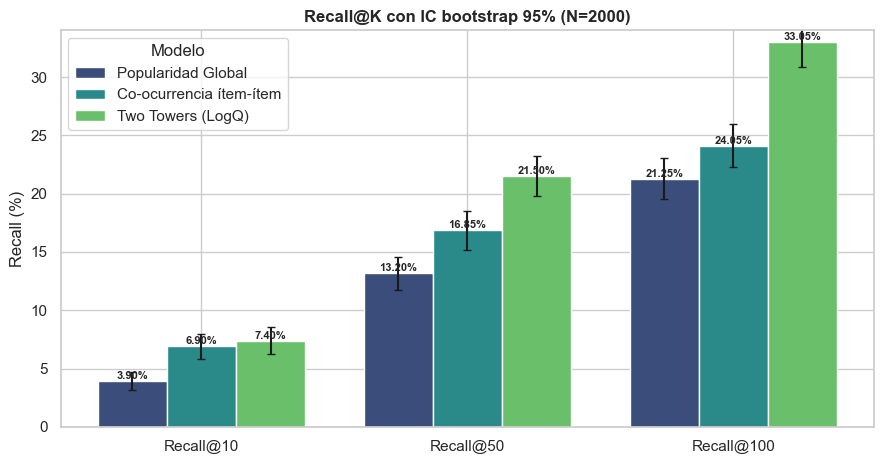

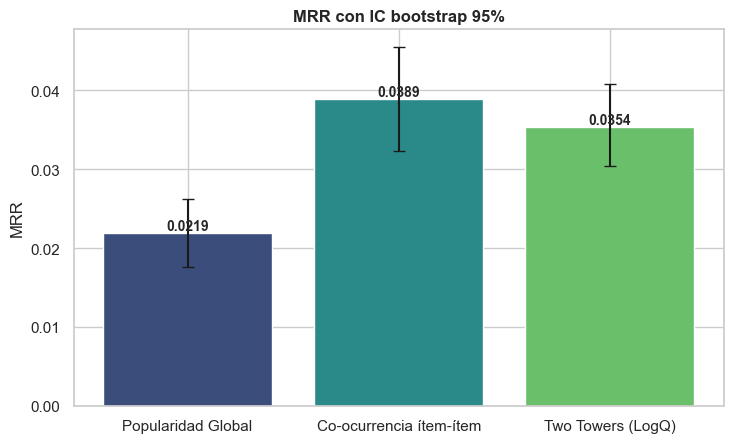

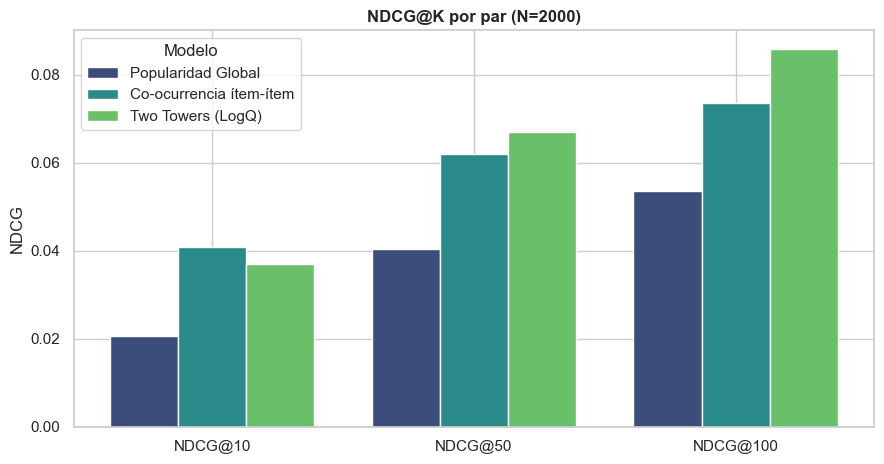

Figuras guardadas en experimentos/ y models/.


In [12]:
def pt_ci(arr):
    pt, lo, hi = boot_ci(arr); return pt, pt - lo, hi - pt
palette = {"Popularidad Global": "#3b4d7a", "Co-ocurrencia ítem-ítem": "#2a8a8a", "Two Towers (LogQ)": "#6abf6a"}

# --- Recall@K con barras de error CI ---
fig, ax = plt.subplots(figsize=(9, 4.8))
x = np.arange(len(K_LIST)); w = 0.26
for mi, (name, rk) in enumerate(models.items()):
    pq = per_query(rk); pts, los, his = [], [], []
    for k in K_LIST:
        p, l, h = pt_ci(pq[f"Recall@{k}"]); pts.append(p*100); los.append(l*100); his.append(h*100)
    ax.bar(x + (mi-1)*w, pts, w, yerr=[los, his], capsize=3, label=name, color=palette[name])
    for xi, p in zip(x + (mi-1)*w, pts):
        ax.annotate(f"{p:.2f}%", (xi, p), ha="center", va="bottom", fontsize=8, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels([f"Recall@{k}" for k in K_LIST])
ax.set_ylabel("Recall (%)"); ax.set_ylim(0, 34)
ax.set_title("Recall@K con IC bootstrap 95% (N=2000)", fontweight="bold")
ax.legend(title="Modelo"); fig.tight_layout()
fig.savefig("experimentos/fig_recall_ci.png", dpi=200)
fig.savefig("models/comparativa_modelos.png", dpi=200); plt.show()

# --- MRR con CI ---
fig, ax = plt.subplots(figsize=(7.5, 4.6))
names = list(models); pts = []; errs = [[], []]
for name in names:
    p, l, h = pt_ci(per_query(models[name])["MRR"]); pts.append(p); errs[0].append(l); errs[1].append(h)
ax.bar(names, pts, yerr=errs, capsize=4, color=[palette[n] for n in names])
for xi, p in enumerate(pts):
    ax.annotate(f"{p:.4f}", (xi, p), ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_ylabel("MRR"); ax.set_title("MRR con IC bootstrap 95%", fontweight="bold"); fig.tight_layout()
fig.savefig("experimentos/fig_mrr_ci.png", dpi=200)
fig.savefig("models/comparativa_mrr.png", dpi=200); plt.show()

# --- NDCG@K ---
fig, ax = plt.subplots(figsize=(9, 4.8))
for mi, (name, rk) in enumerate(models.items()):
    pq = per_query(rk); pts = [pq[f"NDCG@{k}"].mean() for k in K_LIST]
    ax.bar(x + (mi-1)*w, pts, w, label=name, color=palette[name])
ax.set_xticks(x); ax.set_xticklabels([f"NDCG@{k}" for k in K_LIST])
ax.set_ylabel("NDCG"); ax.set_title("NDCG@K por par (N=2000)", fontweight="bold")
ax.legend(title="Modelo"); fig.tight_layout()
fig.savefig("experimentos/fig_ndcg.png", dpi=200); plt.show()
print("Figuras guardadas en experimentos/ y models/.")

## Conclusión

El arnés reproduce la Tabla 11 (Two Towers y popularidad exactos); sobre esa base se añaden NDCG@K, HitRate@K e intervalos de confianza bootstrap del 95 %, y se sustituye el SVD por el baseline clásico de co-ocurrencia ítem-ítem. Los IC muestran que el Two Towers supera a la co-ocurrencia de forma **estadísticamente significativa en Recall@100** (sin solapamiento de intervalos) y marginal en Recall@50, mientras que en Recall@10 y MRR existe **empate estadístico** con ventaja nominal del baseline. Frente a la popularidad global, la superioridad del Two Towers es significativa en todas las métricas. La evaluación agrupada muestra que, con múltiples complementos por consulta, HitRate@K supera a Recall@K y NDCG@K aporta señal de orden.